In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d
import seaborn as sns

In [2]:
def downsample(input_data_df, original_sampling_rate_hz, target_sampling_rate_hz):
    """Downsample the data in the input_data_df from the original sampling rate to a given target sampling rate."""
    data_array = input_data_df.values
    len_data = data_array.shape[0]
    current_x = np.linspace(0, len_data, len_data)
    data_array_downsampled = interp1d(current_x, data_array, axis=0)(
        np.linspace(0, len_data, int(len_data * target_sampling_rate_hz / original_sampling_rate_hz))
    )

    output_data_df = pd.DataFrame(data_array_downsampled, columns=input_data_df.columns)

    return output_data_df

In [3]:
# low_pass_filter_Data
def low_pass_filter(sig, fs, f_cut, order):
    """
    applies zero-lag butterworth filter to a signal
    :param sig: signal to be filtered - np.array
    :param fs: sampling frequency of sig - integer
    :param f_cut: cut-off frequency (low-pass) - integer
    :param order: order of filter - integer
    :return sig_filt: filtered signal - np array
    """
    # design filter
    nf = f_cut/(fs/2)
    b, a = butter(order, nf, btype='low')

    # apply filter
    sig_filt = filtfilt(b, a, sig.values, axis=0, padtype='odd', padlen=3*(max(len(b), len(a))-1))
    return sig_filt

In [4]:
def segment_steps(force_df, fs):
    f_vert = pd.DataFrame(-force_df["Fz"])
     # get highly smoothed signal for peak detection
    highly_smoothed_sig = low_pass_filter(f_vert, fs, 5, 4)

    # grab all smooth peaks above 500 Newtons
    peaks, _ = find_peaks(highly_smoothed_sig.squeeze(), height=500)
    # remove first and last peaks to avoid partial GRFs
    # peaks = np.delete(peaks, [0, -1])

    # squeeze to np array for further processing
    slightly_smoothed_sig = f_vert.values.squeeze()

    # extract HS (search from peak to the left while GRF > 20)
    HS_list = []
    # extract TO (search from peak to the right while GRF > 20)
    TO_list = []

    for peak in peaks:
        peak_hs_copy = peak
        while (peak_hs_copy > 0) & (slightly_smoothed_sig[peak_hs_copy] > 20):
            peak_hs_copy = peak_hs_copy - 1
        HS_list.append(peak_hs_copy + 1)  # go one back

        peak_to_copy = peak
        while (peak_to_copy < len(slightly_smoothed_sig)) & (slightly_smoothed_sig[peak_to_copy] > 20):
            peak_to_copy = peak_to_copy + 1
        TO_list.append(peak_to_copy - 1)  # go on back

    HS_list = list(set(HS_list))  # removes possible duplicates
    HS_list.sort()

    TO_list = list(set(TO_list))  # removes possible duplicates
    TO_list.sort()

    # make sure to start with HS and end with TO
    if HS_list[0] > TO_list[0]:
        HS_list = HS_list[:-1]
        TO_list = TO_list[1:]
    elif HS_list[-1] > TO_list[-1]:
        HS_list = HS_list[:-1]
        TO_list = TO_list[1:]
    try:
        len(TO_list) == len(HS_list)
    except:
        print("different number of HS and TO detected, something is wrong here..")
    
    IC = np.array(HS_list)
    TO = np.array(TO_list)
    return IC, TO

In [5]:
def IC_imu(df, fs):
    racc=np.linalg.norm(df.iloc[:,:3], axis=1)
    IC, _ = find_peaks(racc, distance = fs/4, height = 70000)
    if racc.shape[0]-IC[-1]<fs/4:
        IC = IC[:-1]
    print('number of steps :', len(IC))
    return IC

In [6]:
def TO_imu1(df, IC, fs):
    TO = []
    offset1 = fs//40
    offset2 = fs//4
    for i in range(len(IC)):
        if i < len(IC)-1:
            rgyr = np.linalg.norm(df.iloc[:,3:], axis=1)
            rgyr = rgyr[int(offset1+IC[i]):int(offset2+IC[i])]
        else:
            rgyr = np.linalg.norm(df.iloc[:,3:], axis=1)
            rgyr = rgyr[int(offset1 + IC[i]):]
        peaks, _ = find_peaks(rgyr, distance = fs/4)
        TO.append(peaks[0]+IC[i]+offset1)
    print('number of steps :',len(TO))
    return np.array(TO)

In [7]:
def TO_imu2(df, IC, fs):
    TO = []
    offset1 = fs//40
    offset2 = fs//4
    for i in range(len(IC)):
        if i < len(IC)-1:
            racc = np.linalg.norm(df.iloc[:,:3], axis=1)
            racc = racc[int(offset1+IC[i]):int(offset2+IC[i])]
        else:
            racc = np.linalg.norm(df.iloc[:,:3], axis=1)
            racc = racc[int(offset1 + IC[i]):]
        TO.append(np.argmax(racc)+IC[i]+offset1)
    print('number of steps :',len(TO))
    return np.array(TO)

In [8]:
# import data
df = pd.read_csv('D:\\Salzburg\\TexSense\\Messungen\\PI_FP_IMU\\RUN_03.csv', sep = ',', header = [3], low_memory = False)
ff = df.iloc[df[df['Frame']=='Frame'].index[0]+2:, :]
ff.columns = df.iloc[df[df['Frame']=='Frame'].index[0],:].values.tolist()
force_df = ff[['Frame', 'Sub Frame', 'Fx','Fy','Fz','Mx','My','Mz','Cx','Cy','Cz']].astype('float')
imu_down = df.iloc[1:df[df['Frame']=='Devices'].index[0], :].astype('float')[::2]

In [9]:
# find true peaks force plate
ic_true, to_true = segment_steps(force_df, 1000)
print('number of steps :', len(ic_true))

number of steps : 156


In [10]:
# separate sides
left_foot = imu_down[imu_down.columns[imu_down.columns.str.contains(pat = 'IMU1_')]]
right_foot = imu_down[imu_down.columns[imu_down.columns.str.contains(pat = 'IMU2_')]]

ic_left = IC_imu(left_foot, 1000)
ic_right = IC_imu(right_foot, 1000)

to_left = TO_imu2(left_foot, ic_left, 1000)
to_right = TO_imu2(right_foot, ic_right, 1000)

number of steps : 78
number of steps : 78
number of steps : 78
number of steps : 78


In [36]:
ic_imu=[]
to_imu=[]
for i in range(len(ic_left)):
    ic_imu.append(ic_left[i])
    ic_imu.append(ic_right[i])
    to_imu.append(to_left[i])
    to_imu.append(to_right[i])
    
to_imu1 = np.array(to_imu)
ic_imu = np.array(ic_imu)

Text(0, 0.5, 'Bias [ms]')

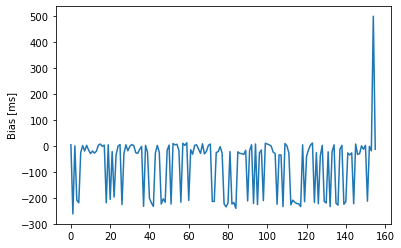

In [37]:
#plt.plot(to_imu2-to_true, label = 'AccNorm')
plt.plot(to_imu1-to_true, label = 'GyrNorm')
plt.ylabel('Bias [ms]')

In [ ]:
i=1

In [ ]:
# TO - max ACC Norm

plt.plot(np.linalg.norm(left_foot.iloc[:,:3], axis=1)[ic_left[i]+50:ic_left[i]+500])
peaks, _ = find_peaks(np.linalg.norm(left_foot.iloc[:,:3], axis=1)[ic_left[i]+50:ic_left[i]+500], distance = 1000/4)
i+=1
peaks

In [ ]:
i=1

In [ ]:
# TO - max Gyr Norm
plt.plot(np.linalg.norm(left_foot.iloc[:,3:], axis=1)[ic_left[i]+50:ic_left[i]+500])
peaks, _ = find_peaks(np.linalg.norm(left_foot.iloc[:,3:], axis=1)[ic_left[i]+50:ic_left[i]+500], distance = 1000/4)
i+=1
peaks

In [ ]:
# example data
sns.set_theme()
fig = plt.figure(figsize=[15,8])
plt.plot(-force_df['Fz'].values[28800:29970])
plt.plot(ict,-force_df['Fz'].values[28800:29970][ict], 'X', color='r', markersize=14, label='true IC')
plt.plot(ici,-force_df['Fz'].values[28800:29970][ici], 'X', color='cyan', markersize=12, label='max AccNorm')
plt.plot(tot,-force_df['Fz'].values[28800:29970][tot], 'o', color='r', markersize=14, label='true TO')
plt.plot(toi1,-force_df['Fz'].values[28800:29970][toi1], 'o', color='lime', markersize=8, label='max GyrNorm')
plt.plot(toi2,-force_df['Fz'].values[28800:29970][toi2], 'o', color='cyan', markersize=8, label='max AccNorm')
plt.xlabel('Time [ms]')
plt.ylabel('F_vert [N]')
plt.legend()

In [ ]:
ict = ic_true[73:76]-28800
ici = ic_imu1[73:76]-28800
tot = to_true[73:76]-28800
toi1 = to_imu1[73:76]-28800
toi2 = to_imu2[73:76]-28800

In [ ]:
toi1

In [ ]:
toi2

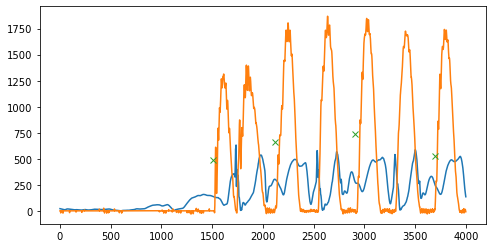

In [54]:
fig = plt.figure(figsize=[8,4])
#plt.plot(np.linalg.norm(left_foot.iloc[:,3:], axis=1)[:4000])
plt.plot(np.linalg.norm(right_foot.iloc[:,3:], axis=1)[:4000])
plt.plot(-force_df['Fz'].values[:4000])
plt.plot(ic_left[:4],np.linalg.norm(left_foot.iloc[:,3:], axis=1)[:4000][ic_left[:4]], 'x')
#plt.plot(ic_right[:4],np.linalg.norm(left_foot.iloc[:,3:], axis=1)[:4000][ic_left[:4]], 'x')

In [47]:
ic_left[:4]

array([1508, 2121, 2911, 3695], dtype=int64)

In [15]:
x=np.linalg.norm(left_foot.iloc[:,:3], axis=1)
left_foot['IMU1_ACC_R']=x

C:\Users\b1090197\AppData\Local\Temp\ipykernel_8920\1720171186.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  left_foot['IMU1_ACC_R']=x


In [52]:
left_res = pd.Series(np.linalg.norm(left_foot.iloc[:,:3]/100, axis = 1), name = 'Acc_Norm left')
right_res = pd.Series(np.linalg.norm(right_foot.iloc[:,:3]/100, axis = 1), name = 'Acc_Norm right')
df = pd.concat([-force_df['Fz'], left_res, right_res], axis=1)


<AxesSubplot:>

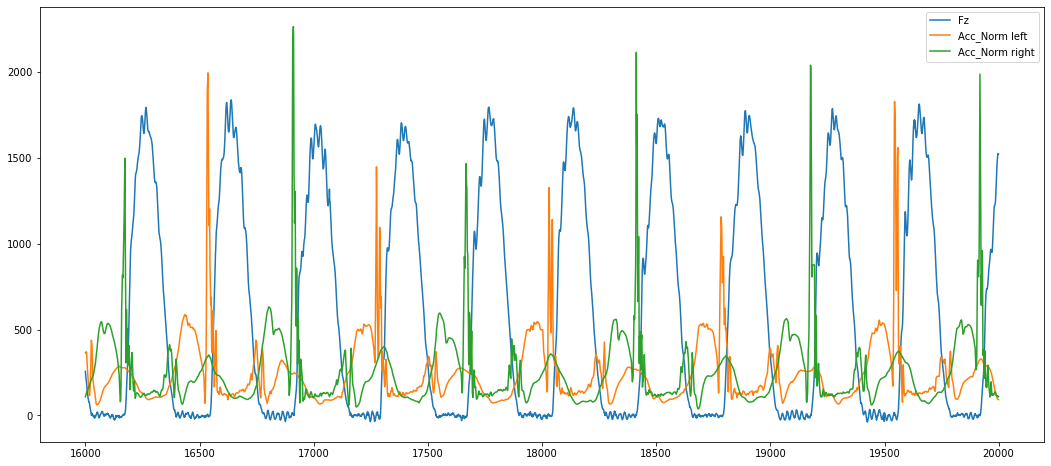

In [58]:
w1 = 16000
w2 = w1+4000
df[w1:w2].plot(figsize=[18,8], )

In [59]:
gyro = left_foot.iloc[:,3:].values
acc = 